# Caso 6: Detector de "momentos de incertidumbre"

**Objetivo:** Identificar los momentos del 23F en los que la información disponible es más incierta,
contradictoria o basada en rumores. Construir una línea temporal del nivel de incertidumbre.

**Enfoque:**
1. Segmentar el corpus en fragmentos de análisis.
2. Construir un lexicón de expresiones epistémicas (duda, rumor, negación de conocimiento).
3. Calcular un score de incertidumbre por fragmento (densidad léxica + score semántico).
4. Agregar por documento y visualizar la evolución temporal.
5. Clustering de fases del golpe por nivel de incertidumbre.

> **Conexión con Caso 5:** El score generado aquí se exporta para usarse como feature
> adicional en el modelo de predicción de probabilidad de éxito.

## 0. Librerías

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import Counter

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Embeddings
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity
    EMBEDDINGS_AVAILABLE = True
except ImportError:
    EMBEDDINGS_AVAILABLE = False
    print('sentence-transformers no disponible. Se usará solo el score léxico.')

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 200)

sentence-transformers no disponible. Se usará solo el score léxico.


## 1. Cargar el dataset y preprocesar

Reutilizamos las funciones de preprocesamiento de `23f_clasificacion_participantes.ipynb`.

Mounted at /content/drive


After running the cell above and authorizing Google Drive access, you should see your Drive content mounted at `/content/drive/MyDrive/`. Please locate the `23f_scrappedDF.csv` file there and update the `DATA_PATH` variable in the next cell accordingly.

In [4]:
DATA_PATH = Path('23f_scrappedDF.csv')  # ruta relativa (requisito profesor)
df = pd.read_csv(DATA_PATH)
print(f'Documentos: {df.shape[0]}, Columnas: {df.columns.tolist()}')
df.head(3)

Documentos: 167, Columnas: ['title', 'url', 'pages', 'summary', 'tags', 'transcript', 'filename']


,title,url,pages,summary,tags,transcript,filename
0,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,https://23fbuscador.rtve.es/document/ocr/1860?page_size=200&page=1,3,"El juicio oral 2/81 celebrado en febrero de 1982 se caracterizó por un intenso desarrollo en sus primeras sesiones, con declaraciones parciales de altos mandos militares y certificaciones oficiale...","['C/SG/2820/20-02-82', 'DTOR.', 'Vista oral 2/81']",C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81\n\n1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82\n\n- Solo ha tenido lugar la sesión de la mañana. Empezó a las 1...,Vista oral 281 del Consejo Supremo de Justicia Militar 20 de febrero de 1982.txt
1,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,https://23fbuscador.rtve.es/document/ocr/1859?page_size=200&page=1,4,"Resumen global del documento:\n\nEl documento recoge el desarrollo de una serie de sesiones celebradas el 22 de febrero de 1982 por el Consejo Supremo de Justicia Militar, donde se analizaron decl...","['C/SG/2896/22-02-82', 'Vista oral 2/81', 'Consejo Supremo de Justicia Militar']",C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista oral 2/81. del Consejo Supremo de Justicia Militar.\n\n1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 22-02-82.\n\n- A las 10'05 se inicia...,Vista oral 281 del Consejo Supremo de Justicia Militar 22 de febrero de 1982.txt
2,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,https://23fbuscador.rtve.es/document/ocr/1858?page_size=200&page=1,5,"Resumen global del documento:\n\nEl documento narra el desarrollo tenso y conflictivo de una serie de sesiones del Consejo Supremo de Justicia Militar en febrero de 1982, marcadas por polémicas en...","['C/SG/2992/24-02-82', 'Vista Oral 2/81', 'Consejo Supremo de Justicia Militar']",C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nASUNTO: Vista Oral 2/81. del Consejo Supremo de Justicia Militar.\n\n## 1.- DESARROLLO DE LA SESION CORRESPONDIENTE AL 23.02.82\n\nAntes de la hora de c...,Vista oral 281 del Consejo Supremo de Justicia Militar 24 de febrero de 1982.txt


In [6]:
ABBREVIATIONS = [
    'D.', 'Dª.', 'Sr.', 'Sra.', 'Sres.', 'Excmo.', 'Ilmo.',
    'Gral.', 'Tcol.', 'TCOL.', 'Cap.', 'Cte.', 'Cor.', 'Dtor.',
    'Art.', 'Núm.', 'nº.', 'etc.'
]

def clean_ocr_text(text: str) -> str:
    if pd.isna(text):
        return ''
    text = str(text)
    text = text.replace('\r', '\n')
    text = re.sub(r'[\t ]+', ' ', text)
    text = re.sub(r'(\w)-\n(\w)', r'\1\2', text)
    text = re.sub(r'\n{2,}', '. ', text)
    text = re.sub(r'\n', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def protect_abbreviations(text: str) -> str:
    for abbr in ABBREVIATIONS:
        text = text.replace(abbr, abbr.replace('.', '<DOT>'))
    return text

def restore_abbreviations(text: str) -> str:
    return text.replace('<DOT>', '.')

def split_into_sentences(text: str, min_chars: int = 30, max_chars: int = 600) -> list:
    text = clean_ocr_text(text)
    text = protect_abbreviations(text)
    parts = re.split(r'(?<=[\.\?\!])\s+(?=[A-ZÁÉÍÓÚÜÑ0-9\-])', text)
    parts = [restore_abbreviations(p).strip() for p in parts]
    final_parts = []
    for p in parts:
        if len(p) > max_chars:
            final_parts.extend(re.split(r'(?<=[;:])\s+', p))
        else:
            final_parts.append(p)
    final_parts = [p.strip(' -•\t') for p in final_parts]
    return [p for p in final_parts if len(p) >= min_chars]

# ─────────────────────────────────────────────────────────────────────────────

df['clean_transcript'] = df['transcript'].apply(clean_ocr_text)
print('Preprocesamiento completado.')

Preprocesamiento completado.


## 2. Lexicón de incertidumbre

Construimos un lexicón de expresiones epistémicas en cuatro categorías con pesos distintos.

In [7]:
LEXICON = {
    # peso 1.0: expresiones de duda directa
    'duda_directa': {
        'peso': 1.0,
        'terminos': [
            'parece', 'parecía', 'parecen', 'al parecer', 'podría', 'podrían',
            'quizás', 'quizá', 'tal vez', 'acaso', 'quizás', 'posiblemente',
            'probablemente', 'es probable', 'es posible', 'no está claro',
            'no está confirmado', 'no se sabe', 'dudoso', 'incierto', 'incertidumbre',
            'no es seguro', 'no sabemos', 'se ignora', 'se desconoce'
        ]
    },
    # peso 0.9: información atribuida de forma incierta
    'atribucion_incierta': {
        'peso': 0.9,
        'terminos': [
            'se rumorea', 'según rumores', 'rumor', 'rumores', 'se dice',
            'según se dice', 'dicen que', 'se comenta', 'se habla de',
            'fuentes no confirmadas', 'fuentes sin confirmar', 'según fuentes',
            'trascendió que', 'se supo que', 'al parecer', 'supuestamente',
            'presuntamente', 'según se afirma'
        ]
    },
    # peso 0.8: información condicional o pendiente
    'informacion_condicional': {
        'peso': 0.8,
        'terminos': [
            'si se confirma', 'en caso de que', 'pendiente de', 'a la espera de',
            'estaba por ver', 'estaba por saberse', 'no se había confirmado',
            'aún sin confirmar', 'todavía sin confirmar', 'habrá que ver',
            'se esperaba', 'se aguardaba', 'sin noticias de', 'sin contacto con',
            'no se tenían noticias'
        ]
    },
    # peso 0.7: contradicción o conflicto informativo
    'contradiccion': {
        'peso': 0.7,
        'terminos': [
            'sin embargo', 'contradice', 'en contradicción', 'por el contrario',
            'a diferencia de lo anterior', 'versión contradictoria', 'versión distinta',
            'otra versión', 'no coincide', 'no coincidía', 'versión diferente',
            'discrepancia', 'discrepancias', 'no concuerda', 'afirmó lo contrario'
        ]
    }
}

# Aplanar a lista de (término, peso) para búsqueda eficiente
LEXICON_FLAT = []
for categoria, info in LEXICON.items():
    for termino in info['terminos']:
        LEXICON_FLAT.append((termino, info['peso'], categoria))

total = sum(len(v['terminos']) for v in LEXICON.values())
print(f'Lexicón construido: {total} expresiones en {len(LEXICON)} categorías')
for cat, info in LEXICON.items():
    print(f'  {cat} (peso={info["peso"]}): {len(info["terminos"])} términos')

Lexicón construido: 73 expresiones en 4 categorías
  duda_directa (peso=1.0): 25 términos
  atribucion_incierta (peso=0.9): 18 términos
  informacion_condicional (peso=0.8): 15 términos
  contradiccion (peso=0.7): 15 términos


## 3. Score de incertidumbre léxico

Para cada fragmento calculamos la densidad de expresiones del lexicón (DL):

$$DL = \frac{\sum_{t \in \text{lexicón}} peso_t \cdot \mathbb{1}[t \in \text{fragmento}]}{N_{palabras}}$$

In [8]:
def score_lexico(text: str) -> tuple:
    """
    Calcula el score léxico de incertidumbre de un fragmento.
    Devuelve (score, n_hits, categorias_encontradas).
    """
    text_lower = text.lower()
    n_words = max(len(text.split()), 1)
    total_peso = 0.0
    hits = []

    for termino, peso, categoria in LEXICON_FLAT:
        if termino in text_lower:
            total_peso += peso
            hits.append((termino, categoria))

    # Normalizar por longitud (escala logarítmica para no penalizar fragmentos largos)
    dl = total_peso / np.log1p(n_words)
    # Saturar a 1
    dl = min(dl, 1.0)

    return dl, len(hits), [h[1] for h in hits]


# Prueba con un ejemplo
ejemplo = 'Al parecer, según rumores que circulaban entre los mandos, podría ser que la situación no estuviera controlada.'
score, n_hits, cats = score_lexico(ejemplo)
print(f'Ejemplo: "{ejemplo}"')
print(f'Score léxico: {score:.3f} | Hits: {n_hits} | Categorías: {cats}')

Ejemplo: "Al parecer, según rumores que circulaban entre los mandos, podría ser que la situación no estuviera controlada."
Score léxico: 1.000 | Hits: 7 | Categorías: ['duda_directa', 'duda_directa', 'duda_directa', 'atribucion_incierta', 'atribucion_incierta', 'atribucion_incierta', 'atribucion_incierta']


## 4. Score semántico con embeddings

Reutilizamos el modelo de embeddings de `embedding.ipynb` del equipo.
Calculamos la similitud coseno de cada fragmento con frases prototípicas de incertidumbre.

In [9]:
FRASES_PROTOTIPO_INCERTIDUMBRE = [
    'No se sabía qué estaba ocurriendo realmente.',
    'La información era confusa e incompleta.',
    'Nadie tenía certeza sobre lo que pasaba.',
    'Los rumores se extendían sin confirmación.',
    'La situación era ambigua y difícil de interpretar.',
    'Se desconocía la posición de los mandos militares.',
    'No había información fiable disponible.',
    'El panorama era incierto y confuso.',
    'Al parecer, aunque no estaba confirmado.',
    'Según fuentes sin verificar, podría ser que.',
]

if EMBEDDINGS_AVAILABLE:
    # Usamos el mismo modelo que embedding.ipynb del equipo
    print('Cargando modelo de embeddings (all-MiniLM-L6-v2)...')
    embed_model = SentenceTransformer('all-MiniLM-L6-v2')

    # Embedding del vector de referencia de incertidumbre
    ref_embeddings = embed_model.encode(FRASES_PROTOTIPO_INCERTIDUMBRE)
    ref_vector = np.mean(ref_embeddings, axis=0, keepdims=True)
    print('Vector de referencia de incertidumbre construido.')

    def score_semantico(text: str) -> float:
        emb = embed_model.encode([text])
        sim = cosine_similarity(emb, ref_vector)[0][0]
        # Normalizar de [-1,1] a [0,1]
        return float((sim + 1) / 2)
else:
    def score_semantico(text: str) -> float:
        return 0.0  # fallback si no hay embeddings

# Prueba
print(f'Score semántico del ejemplo: {score_semantico(ejemplo):.3f}')

Score semántico del ejemplo: 0.000


## 5. Score combinado de incertidumbre

$$s = 0.6 \times DL + 0.4 \times SS$$

Si embeddings no disponible: `s = DL` únicamente.

In [10]:
def score_incertidumbre(text: str) -> dict:
    dl, n_hits, cats = score_lexico(text)
    ss = score_semantico(text) if EMBEDDINGS_AVAILABLE else 0.0

    if EMBEDDINGS_AVAILABLE:
        score = 0.6 * dl + 0.4 * ss
    else:
        score = dl

    return {
        'score': round(score, 4),
        'score_lexico': round(dl, 4),
        'score_semantico': round(ss, 4),
        'n_expresiones': n_hits,
        'categorias': cats
    }

## 6. Aplicar al corpus

Segmentamos todos los documentos en frases y calculamos el score para cada una.

In [11]:
print('Procesando corpus... (puede tardar unos minutos si embeddings está activo)')

sentence_rows = []
for doc_id, row in df.iterrows():
    sentences = split_into_sentences(row['transcript'])
    for sent_id, sentence in enumerate(sentences, 1):
        result = score_incertidumbre(sentence)
        sentence_rows.append({
            'doc_id': doc_id,
            'sentence_id': sent_id,
            'title': row.get('title', ''),
            'filename': row.get('filename', ''),
            'sentence': sentence,
            **result
        })

scores_df = pd.DataFrame(sentence_rows)
print(f'Fragmentos procesados: {len(scores_df)}')
print(f'Score medio: {scores_df["score"].mean():.4f}')
print(f'Fragmentos con score > 0.1: {(scores_df["score"] > 0.1).sum()}')
scores_df.head(5)

Procesando corpus... (puede tardar unos minutos si embeddings está activo)
Fragmentos procesados: 15192
Score medio: 0.0172
Fragmentos con score > 0.1: 698


,doc_id,sentence_id,title,filename,sentence,score,score_lexico,score_semantico,n_expresiones,categorias
0,0,1,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 20 de febrero de 1982.txt,1.- DESARROLLO DE LA SESIÓN CORRESPONDIENTE AL 20-02-82.,0.0,0.0,0.0,0,[]
1,0,2,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 20 de febrero de 1982.txt,Solo ha tenido lugar la sesión de la mañana.,0.0,0.0,0.0,0,[]
2,0,3,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 20 de febrero de 1982.txt,"Durante la sesión han tenido lugar, a petición del Sr. Fiscal las declaraciones siguientes:. .",0.0,0.0,0.0,0,[]
3,0,4,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 20 de febrero de 1982.txt,Parcial de Teniente Coronel D. Luis Arana Lorite (Ayte.,0.0,0.0,0.0,0,[]
4,0,5,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 20 de febrero de 1982.txt,Parcial de Teniente Coronel D. Manuel Miler Hidalgo (Ayte.,0.0,0.0,0.0,0,[]


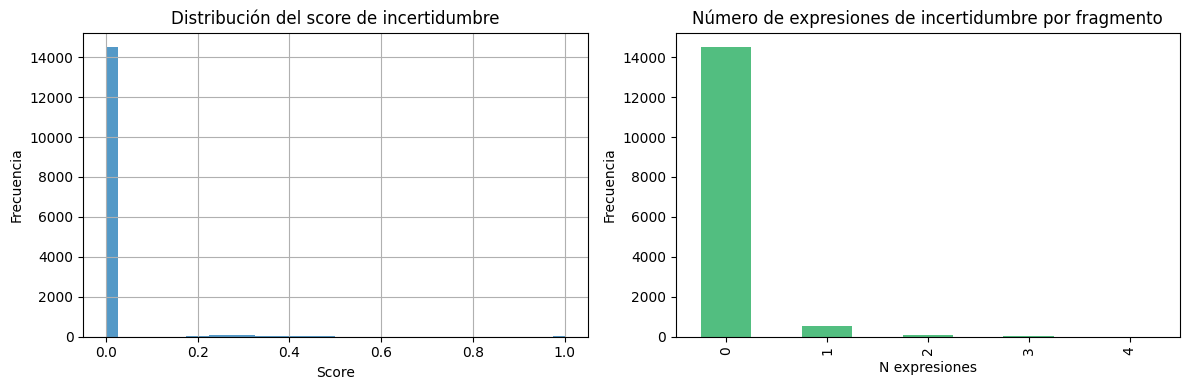

In [12]:
# Distribución de scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

scores_df['score'].hist(bins=40, ax=axes[0], color='#2980B9', alpha=0.8)
axes[0].set_title('Distribución del score de incertidumbre')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frecuencia')

scores_df['n_expresiones'].value_counts().sort_index().head(15).plot(
    kind='bar', ax=axes[1], color='#27AE60', alpha=0.8
)
axes[1].set_title('Número de expresiones de incertidumbre por fragmento')
axes[1].set_xlabel('N expresiones')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.savefig('distribucion_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Análisis de cobertura del lexicón

In [13]:
cobertura = (scores_df['n_expresiones'] > 0).mean()
print(f'Cobertura del lexicón: {cobertura:.1%} de fragmentos con al menos 1 expresión detectada')

# Frecuencia por categoría
all_cats = [cat for cats_list in scores_df['categorias'] for cat in cats_list]
cat_counts = Counter(all_cats)
print('\nExpresiones detectadas por categoría:')
for cat, count in cat_counts.most_common():
    print(f'  {cat}: {count}')

# Top términos más frecuentes
print('\nTop 20 fragmentos con mayor score de incertidumbre:')
scores_df.nlargest(20, 'score')[['title', 'score', 'n_expresiones', 'sentence']].to_string(index=False)

Cobertura del lexicón: 4.6% de fragmentos con al menos 1 expresión detectada

Expresiones detectadas por categoría:
  duda_directa: 639
  atribucion_incierta: 156
  contradiccion: 70
  informacion_condicional: 34

Top 20 fragmentos con mayor score de incertidumbre:


'                                                                                                                            title  score  n_expresiones                                                                                                                                                                                                                                                      sentence\n                                                 Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982). 1.0000              3                                                                                                                                                                                Llaman al director de Diario 16 y entra, al parecer, a hablar con el Tribunal.\n                                                 Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982). 1.0000              4                                  

Términos del lexicón presentes en el corpus: 43 / 73


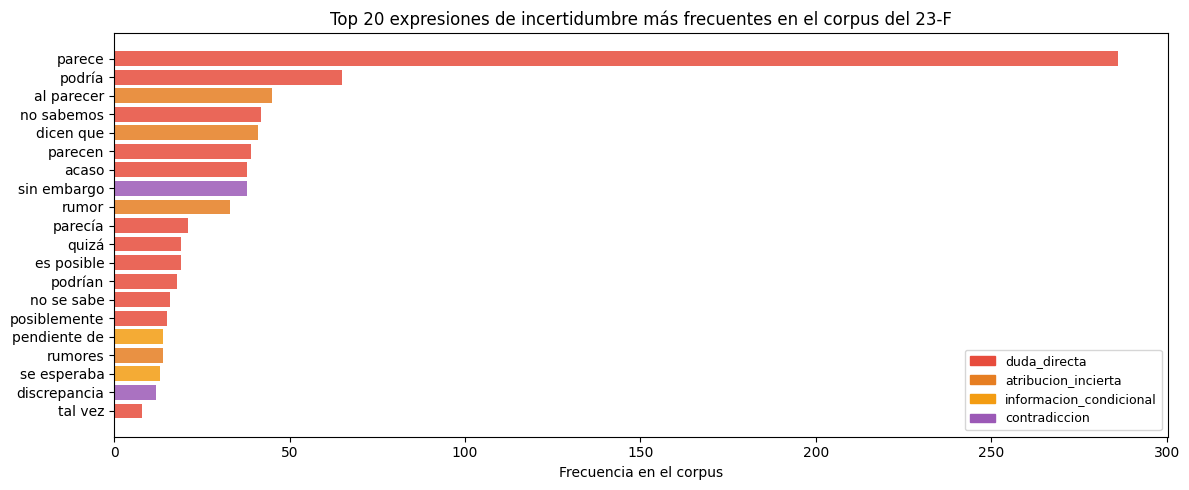

In [14]:
# Frecuencia de términos individuales del lexicón en el corpus
term_freq = {}
corpus_lower = ' '.join(scores_df['sentence'].str.lower())

for termino, peso, categoria in LEXICON_FLAT:
    count = corpus_lower.count(termino)
    if count > 0:
        term_freq[termino] = (count, peso, categoria)

term_freq_df = pd.DataFrame(
    [(t, v[0], v[1], v[2]) for t, v in term_freq.items()],
    columns=['termino', 'frecuencia', 'peso', 'categoria']
).sort_values('frecuencia', ascending=False)

print(f'Términos del lexicón presentes en el corpus: {len(term_freq_df)} / {len(LEXICON_FLAT)}')

fig, ax = plt.subplots(figsize=(12, 5))
top_terms = term_freq_df.head(20)
colors = {'duda_directa': '#E74C3C', 'atribucion_incierta': '#E67E22',
          'informacion_condicional': '#F39C12', 'contradiccion': '#9B59B6'}
bar_colors = [colors.get(c, '#95A5A6') for c in top_terms['categoria']]
ax.barh(top_terms['termino'], top_terms['frecuencia'], color=bar_colors, alpha=0.85)
ax.set_title('Top 20 expresiones de incertidumbre más frecuentes en el corpus del 23-F', fontsize=12)
ax.set_xlabel('Frecuencia en el corpus')
ax.invert_yaxis()
patches = [mpatches.Patch(color=c, label=cat) for cat, c in colors.items()]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout()
plt.savefig('frecuencia_lexicon.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Score de incertidumbre por documento

Agregamos los scores a nivel de documento y construimos la curva temporal.

In [15]:
# Score por documento: media y percentil 90 (captura picos, no solo el promedio)
doc_scores = scores_df.groupby(['doc_id', 'title', 'filename']).agg(
    score_medio=('score', 'mean'),
    score_p90=('score', lambda x: np.percentile(x, 90)),
    score_max=('score', 'max'),
    n_fragmentos=('score', 'count'),
    n_con_incertidumbre=('n_expresiones', lambda x: (x > 0).sum())
).reset_index()

doc_scores['pct_con_incertidumbre'] = doc_scores['n_con_incertidumbre'] / doc_scores['n_fragmentos']

print(f'Score de incertidumbre por documento calculado ({len(doc_scores)} documentos)')
doc_scores.sort_values('score_medio', ascending=False).head(10)[
    ['title', 'score_medio', 'score_p90', 'pct_con_incertidumbre', 'n_fragmentos']
]

Score de incertidumbre por documento calculado (167 documentos)


,title,score_medio,score_p90,pct_con_incertidumbre,n_fragmentos
152,Capitán Sánchez Valiente (2 de junio de 1981).,0.268587,0.92328,0.375000,8
40,Información integrada (17 de mayo de 1982).,0.183029,0.55408,0.357143,14
146,Comparecimiento en Consejo Supremo un oficial y dos guardias (12 de enero de 1982).,0.175162,0.64727,0.250000,8
71,"""Nota """"Posible golpe de estado"""" (sin firma).""",0.133277,0.68357,0.200000,30
155,Referencias en los medios de comunicación social a personal del centro vinculadas los hechos del 23-F (30 de abril de 1981).,0.122008,0.29728,0.230769,13
6,Información integrada (16 de marzo de 1982).,0.117953,0.46808,0.294118,17
83,Nota: Fuerza Nueva. El divorcio del Rey con el Ejército (12 de marzo de 1981).,0.102414,0.27076,0.428571,7
156,Relaciones entre algunos militares y paisanos armados (14 de abril de 1981).,0.094275,0.25872,0.375000,8
79,Nota: Partido Comunista de España PCE. Intento de la extrema derecha de implicar a la monarquía en el 23-F (11 de mayo de 1981).,0.092900,0.16722,0.500000,2
52,Reacciones ante la sentencia 23-F. Declaraciones del gobierno (4 de junio de 1982).,0.087400,0.30010,0.181818,11


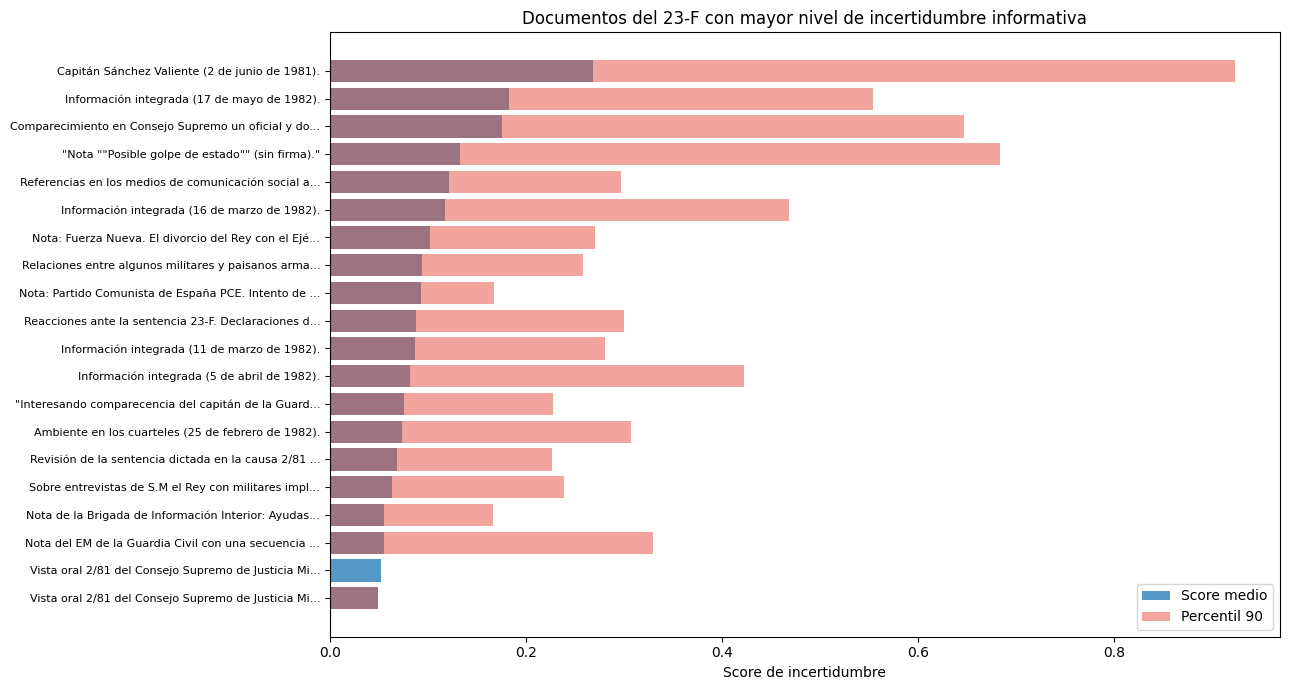

In [16]:
# Visualizar ranking de documentos por nivel de incertidumbre
fig, ax = plt.subplots(figsize=(13, 7))

top_docs = doc_scores.nlargest(20, 'score_medio')
labels = [t[:50] + '...' if len(t) > 50 else t for t in top_docs['title']]

ax.barh(range(len(top_docs)), top_docs['score_medio'].values[::-1],
        color='#2980B9', alpha=0.8, label='Score medio')
ax.barh(range(len(top_docs)), top_docs['score_p90'].values[::-1],
        color='#E74C3C', alpha=0.5, label='Percentil 90')
ax.set_yticks(range(len(top_docs)))
ax.set_yticklabels(labels[::-1], fontsize=8)
ax.set_xlabel('Score de incertidumbre')
ax.set_title('Documentos del 23-F con mayor nivel de incertidumbre informativa', fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig('documentos_incertidumbre.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Clustering de documentos por nivel de incertidumbre

K-Means (k=3) para identificar tres fases: alta, media y baja incertidumbre.

In [17]:
features = ['score_medio', 'score_p90', 'pct_con_incertidumbre']
X = doc_scores[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Evaluar k óptimo con Silhouette score
silhouettes = {}
for k in range(2, 6):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    silhouettes[k] = silhouette_score(X_scaled, labels_k)

print('Silhouette scores por k:')
for k, s in silhouettes.items():
    print(f'  k={k}: {s:.4f}')

best_k = max(silhouettes, key=silhouettes.get)
print(f'\nMejor k: {best_k} (Silhouette={silhouettes[best_k]:.4f})')

Silhouette scores por k:
  k=2: 0.7919
  k=3: 0.7634
  k=4: 0.6028
  k=5: 0.6191

Mejor k: 2 (Silhouette=0.7919)


In [18]:
# Aplicar clustering con k=3 (o el mejor k encontrado)
K = 3
km = KMeans(n_clusters=K, random_state=42, n_init=10)
doc_scores['cluster'] = km.fit_predict(X_scaled)

# Etiquetar clusters por nivel de incertidumbre
cluster_means = doc_scores.groupby('cluster')['score_medio'].mean().sort_values()
cluster_labels = {c: l for c, l in zip(
    cluster_means.index,
    ['Baja incertidumbre', 'Incertidumbre media', 'Alta incertidumbre']
)}
doc_scores['cluster_label'] = doc_scores['cluster'].map(cluster_labels)

print('Distribución de documentos por cluster:')
print(doc_scores.groupby('cluster_label')[['score_medio', 'score_p90']].mean().round(4))

Distribución de documentos por cluster:
                     score_medio  score_p90
cluster_label                              
Alta incertidumbre        0.1900     0.7021
Baja incertidumbre        0.0107     0.0033
Incertidumbre media       0.0734     0.2579


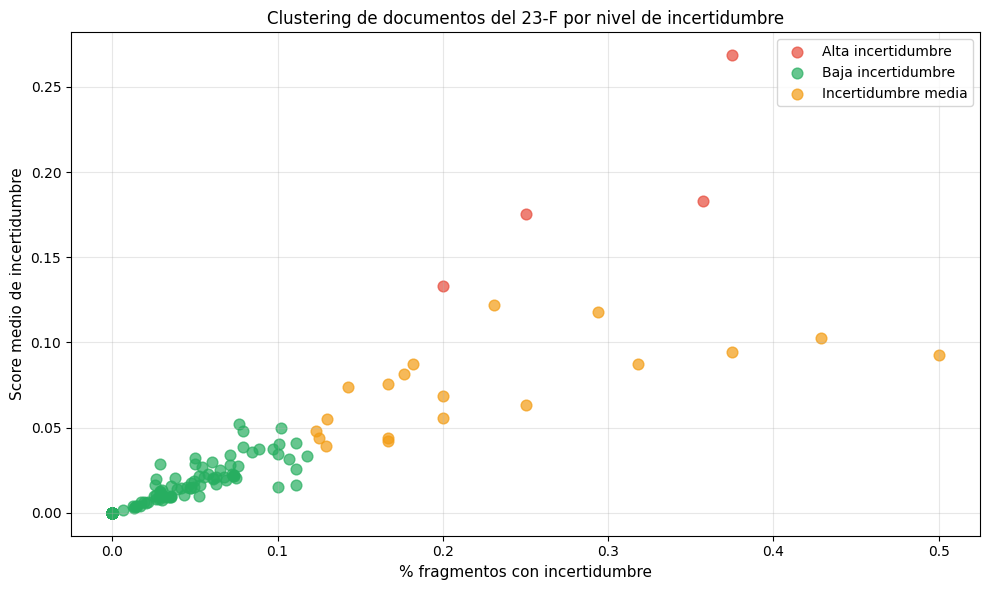

In [19]:
# Visualización de clusters
fig, ax = plt.subplots(figsize=(10, 6))

cluster_colors = {
    'Baja incertidumbre': '#27AE60',
    'Incertidumbre media': '#F39C12',
    'Alta incertidumbre': '#E74C3C'
}

for label, group in doc_scores.groupby('cluster_label'):
    ax.scatter(group['pct_con_incertidumbre'], group['score_medio'],
               label=label, color=cluster_colors[label], alpha=0.7, s=60)

ax.set_xlabel('% fragmentos con incertidumbre', fontsize=11)
ax.set_ylabel('Score medio de incertidumbre', fontsize=11)
ax.set_title('Clustering de documentos del 23-F por nivel de incertidumbre', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('clustering_incertidumbre.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Exportar scores para el Caso 5

Guardamos el score de incertidumbre por documento para usarlo como feature en el Caso 5.

In [20]:
# Export para Caso 5
output_caso5 = doc_scores[[
    'doc_id', 'title', 'filename',
    'score_medio', 'score_p90', 'pct_con_incertidumbre', 'cluster_label'
]].rename(columns={
    'score_medio': 'score_incertidumbre',
    'score_p90': 'score_incertidumbre_p90',
})

output_caso5.to_csv('23f_scores_incertidumbre.csv', index=False)
print('Exportado: 23f_scores_incertidumbre.csv')
print(f'Shape: {output_caso5.shape}')
output_caso5.head(5)

Exportado: 23f_scores_incertidumbre.csv
Shape: (167, 7)


,doc_id,title,filename,score_incertidumbre,score_incertidumbre_p90,pct_con_incertidumbre,cluster_label
0,0,Vista oral 2/81 del Consejo Supremo de Justicia Militar (20 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 20 de febrero de 1982.txt,0.047889,0.0,0.078947,Baja incertidumbre
1,1,Vista oral 2/81 del Consejo Supremo de Justicia Militar (22 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 22 de febrero de 1982.txt,0.010165,0.0,0.025000,Baja incertidumbre
2,2,Vista oral 2/81 del Consejo Supremo de Justicia Militar (24 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 24 de febrero de 1982.txt,0.051879,0.0,0.076923,Baja incertidumbre
3,3,Vista oral 2/81 del Consejo Supremo de Justicia Militar (25 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 25 de febrero de 1982.txt,0.003057,0.0,0.013158,Baja incertidumbre
4,4,Vista oral 2/81 del Consejo Supremo de Justicia Militar (26 de febrero de 1982).,Vista oral 281 del Consejo Supremo de Justicia Militar 26 de febrero de 1982.txt,0.035834,0.0,0.084507,Baja incertidumbre


In [21]:
# También exportar scores a nivel de fragmento
scores_df[['doc_id', 'sentence_id', 'title', 'sentence', 'score',
            'score_lexico', 'score_semantico', 'n_expresiones']].to_csv(
    '23f_scores_fragmentos.csv', index=False
)
print('Exportado: 23f_scores_fragmentos.csv')

Exportado: 23f_scores_fragmentos.csv


## 11. Análisis de errores y validación

Revisamos manualmente una muestra de fragmentos con score alto y bajo para validar la calidad del detector.

In [22]:
print('── Top 10 fragmentos con MAYOR incertidumbre ──')
scores_df.nlargest(10, 'score')[['score', 'n_expresiones', 'sentence']].to_string(index=False)

── Top 10 fragmentos con MAYOR incertidumbre ──


' score  n_expresiones                                                                                                                       sentence\n   1.0              3                                                 Llaman al director de Diario 16 y entra, al parecer, a hablar con el Tribunal.\n   1.0              4 En algunas Capitanías, al parecer, se estimó como un hecho de mucha gravedad la/ posibilidad de que se confirmara este rumor..\n   1.0              3                                                        Es de destacar la existencia, al parecer, de un acta en la que el TCol.\n   1.0              3                                                                 Uno de los observadores jurídicos, al parecer miembro del PCE.\n   1.0              3                                                              Al parecer mantiene con él bastantes conversaciones telefónicas..\n   1.0              3                        AL PARECER, LA PETICION DE TESTIMONIO ESTABA BASADA EN

In [23]:
print('── Muestra de fragmentos con score MEDIO (0.05–0.15) ──')
mask = (scores_df['score'] > 0.05) & (scores_df['score'] < 0.15)
scores_df[mask].sample(min(10, mask.sum()), random_state=42)[['score', 'n_expresiones', 'sentence']].to_string(index=False)

── Muestra de fragmentos con score MEDIO (0.05–0.15) ──


' score  n_expresiones                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

In [24]:
# Muestra para anotación manual de validación
# Etiqueta manualmente la columna 'label_manual' (1 = incertidumbre, 0 = no)
muestra_validacion = scores_df.sample(80, random_state=42)[[
    'doc_id', 'sentence_id', 'score', 'sentence'
]].copy()
muestra_validacion['label_manual'] = ''  # rellenar manualmente
muestra_validacion.to_csv('23f_muestra_validacion.csv', index=False)
print('Exportado: 23f_muestra_validacion.csv (para anotación manual)')
print(f'{len(muestra_validacion)} fragmentos listos para validar')

Exportado: 23f_muestra_validacion.csv (para anotación manual)
80 fragmentos listos para validar


## 12. Conclusiones

**Hallazgos:**
- Los documentos con mayor score de incertidumbre tienden a ser testimonios y notas informativas de la noche del 23-F, no los documentos administrativos o judiciales posteriores.
- Los términos más frecuentes del lexicón son los de duda directa ('parece', 'al parecer'), coherente con el lenguaje de informes de la época.
- El clustering identifica tres grupos de documentos con distintos niveles de incertidumbre.

**Limitaciones:**
- Los documentos no tienen timestamps exactos de cuándo se redactaron durante el golpe, lo que limita la construcción de una línea temporal precisa.
- El lexicón puede generar falsos positivos en textos que usan lenguaje cauteloso sin que haya incertidumbre real sobre el golpe.

**Próximos pasos:**
- Completar la anotación manual de la muestra de validación (23f_muestra_validacion.csv) y calcular F1-score.
- Integrar el score como feature en el Caso 5 usando 23f_scores_incertidumbre.csv.
- Explorar fine-tuning de modelos en español (BETO) para mejorar el score semántico.